<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/06_Lab_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Notebook basado en biotrain latam https://github.com/biotrain-latam/BiotrAIn-pilot-course,

# Deep Learning for Molecular Property Prediction: A Comprehensive Guide

Welcome to this comprehensive deep learning tutorial! We'll explore how to build and train neural networks for predicting molecular properties, specifically solubility.

## What We'll Cover

1. **Setting up**
   - Install libraries and download data
   - Pytorch

1. **Data Understanding & Exploration**
   - Dataset analysis and visualization
   - Molecular descriptors
   - Data spliting

2. **Deep Learning Fundamentals**
   - What is a neural network?
   - Architecture components
   - Hyperparameters explanation

3. **Model Development**
   - Building a neural network from scratch
   - Training process understanding
   - Hyperparameter optimization using grid search

4. **Model Evaluation**
   - Performance metrics
   - Results analysis



# **1. Setting up**

### **Install libraries and download data**

In [2]:
# Install all libraries
! pip install pytorch-lightning wandb rdkit ogb deepchem torch

# Download all data
! mkdir -p data/
# TODO: Download the ESOL dataset from https://acs.figshare.com/ndownloader/files/14790314 and save it to data/ as ESOL.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 55.4 MB/s eta 0:00:00


In [4]:
import pandas as pd

df=pd.read_csv("data/ci034243x_si_001.txt")
df

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.180,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.000,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.740,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.480,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.040,-3.077,FC(F)(Cl)C(F)(Cl)Cl
...,...,...,...,...
1139,vamidothion,1.144,-1.446,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
1140,Vinclozolin,-4.925,-4.377,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C
1141,Warfarin,-3.893,-3.913,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O
1142,Xipamide,-3.790,-3.642,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O


### **Pytorch**
#### What is Pytorch?
Based on the Torch library, PyTorch is one of the most popular deep learning frameworks for machine learning practitioners. We will learn to use PyTorch to do deep learning work. You can also browse the PyTorch [tutorials](https://pytorch.org/tutorials/) and [docs](https://pytorch.org/docs/stable/index.html) for additional details.

#### Pytorch Lightning
PyTorch Lightning is the deep learning framework for professional AI researchers and machine learning engineers who need maximal flexibility without sacrificing performance at scale. You can also browse its [documentation](https://pytorch-lightning.readthedocs.io/en/stable/) for additional details.

Let´s start by setting a random seed to ensure repeatability of experiments

In [5]:
import random
import numpy as np
import torch

# Random Seeds and Reproducibility
torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
random.seed(0)

# **2. Understanding Our Data**

## The ESOL Dataset
We're working with the [ESOL](https://acs.figshare.com/articles/dataset/ESOL_Estimating_Aqueous_Solubility_Directly_from_Molecular_Structure/7944677?file=14790314) (Estimated SOLubility) dataset, which contains:
- **Compound ID**: Unique identifier for each compound.
- **Measured log(solubility:mol/L)**: Experimental solubility values in log mol/L.
- **ESOL predicted log(solubility:mol/L)**: Predicted solubility values using the ESOL method.
- **SMILES**: Simplified Molecular Input Line Entry System representation of the molecular structure.

### What is SMILES?
SMILES (Simplified Molecular Input Line Entry System) is a line notation for describing the structure of chemical species using short ASCII strings. For example:
- `CC(=O)O` represents acetic acid (CH₃COOH)
- `C1=CC=CC=C1` represents benzene
- `O` represents water (H₂O)

Key SMILES syntax:
- Letters represent atoms (C=carbon, O=oxygen, N=nitrogen, etc.)
- Numbers indicate rings
- `=` represents double bonds
- `#` represents triple bonds
- Branching is shown with parentheses
- Square brackets `[]` are used for more complex cases

Here is an example of a molecule represented as SMILES
<div align="left">
    <figure>
        <img src="https://github.com/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/Example_SMILES.png?raw=1" alt="Molecule SMILES Example" width="400"/>
        <figcaption><i>Example of a molecule and its SMILES representation</i></figcaption>
    </figure>
</div>

### Why Solubility Prediction?
Solubility is a crucial property in drug development and chemical processes. Accurate prediction can:
- Speed up drug discovery
- Reduce experimental costs
- Help in formulation development

### Data Preprocessing
Let's start by exploring our data:



In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw, AllChem

# TODO: Load ESOL data in a pandas dataframe keeping only "measured log" and "SMILES" columns
# then show the first 5 rows of your dataframe


In [8]:
Cols = ["measured log(solubility:mol/L)", "SMILES"]
df = df[Cols]
df

,measured log(solubility:mol/L),SMILES
0,-2.180,ClCC(Cl)(Cl)Cl
1,-2.000,CC(Cl)(Cl)Cl
2,-1.740,ClC(Cl)C(Cl)Cl
3,-1.480,ClCC(Cl)Cl
4,-3.040,FC(F)(Cl)C(F)(Cl)Cl
...,...,...
1139,1.144,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
1140,-4.925,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C
1141,-3.893,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O
1142,-3.790,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O


### Visualization of Molecular Structures and Solubility

Now we will visualize some molecules from the dataset along with their solubility values. This will help us better understand the relationship between molecular structure and the property we want to predict.

In [9]:
df

,measured log(solubility:mol/L),SMILES
0,-2.180,ClCC(Cl)(Cl)Cl
1,-2.000,CC(Cl)(Cl)Cl
2,-1.740,ClC(Cl)C(Cl)Cl
3,-1.480,ClCC(Cl)Cl
4,-3.040,FC(F)(Cl)C(F)(Cl)Cl
...,...,...
1139,1.144,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
1140,-4.925,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C
1141,-3.893,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O
1142,-3.790,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O


In [11]:
smiles=df['SMILES'][0]
smiles

'ClCC(Cl)(Cl)Cl'

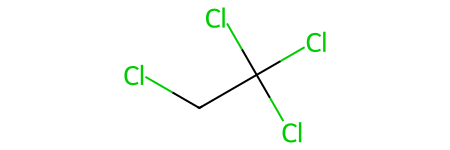

In [12]:
rdkit_mol = Chem.MolFromSmiles(smiles)
rdkit_mol

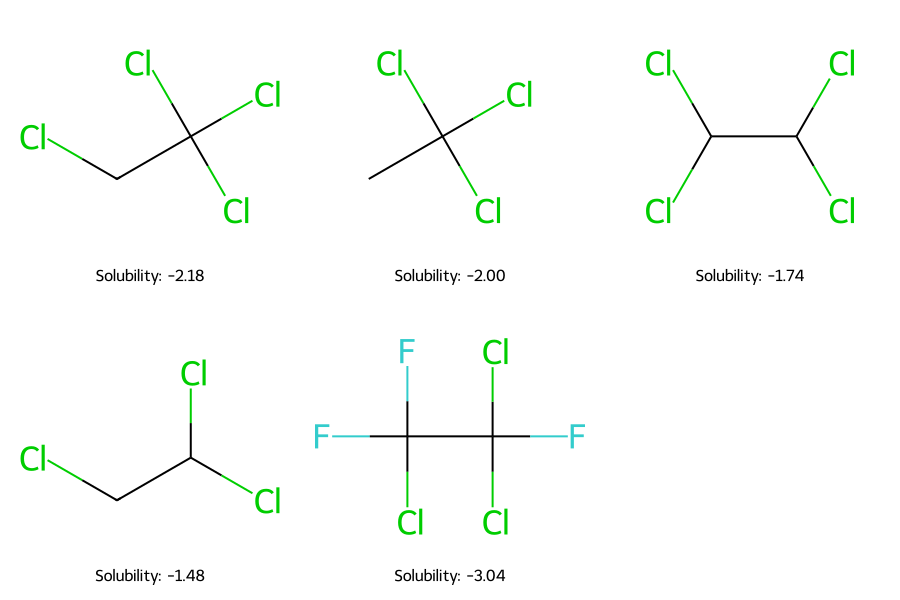

In [13]:
def visualize_molecules(df, n_molecules=6):
    # Create a list to store the molecule images
    imgs = []
    legends = []

    for idx in range(min(n_molecules, len(df))):

    # TODO:
    # For each molecule in the dataset:
    # 1. Retrieve the SMILES string from the current row and store it in a variable called `smiles`.

    # 2. Retrieve the corresponding solubility value and store it in a variable called `solubility`.

    # 3. Convert the SMILES string into an RDKit molecule object using Chem and store it in a variable called `mol`.

    # Hints:
    # - Use the current index (idx) to access the DataFrame row.
    # - Identify the correct column names for SMILES and solubility.
    # - Use an RDKit function to convert SMILES → molecule object.

    # YOUR CODE HERE
      smiles=df['SMILES'][idx]
      solubility=df['measured log(solubility:mol/L)'][idx]
      mol = Chem.MolFromSmiles(smiles)
      if mol is None:
        continue
    # TODO (Validation):
    # Ensure that `mol` is valid (not None).If it´s not valid skip this iteration to avoid errors in later steps.

    # YOUR CODE HERE


    # Generate 2D coordinates for better visualization
      AllChem.Compute2DCoords(mol)

    # Append the molecule and its legend to the respective lists
      imgs.append(mol)
      legends.append(f'Solubility: {solubility:.2f}')

    # Create a grid of molecule images
    img = Draw.MolsToGridImage(
        imgs,
        legends=legends,  # Add legends with solubility values
        molsPerRow=3,  # Number of molecules per row
        subImgSize=(300, 300),  # Size of each sub-image
        returnPNG=False  # Return as an image object, not PNG
    )
    return img

# Visualize the first 5 molecules in the dataset
img = visualize_molecules(df.iloc[0:5])
img

## Molecular Descriptors

Molecular descriptors are numerical values that describe the properties of molecules. These descriptors are widely used in cheminformatics and machine learning for tasks such as property prediction, similarity analysis, and clustering.


Let´s check what is a molecule descriptor. First we need to transform SMILES into a molecule object

In [16]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# Convert SMILES to RDKit mol objects
mols = [Chem.MolFromSmiles(x) for x in df['SMILES']]
mols = [x for x in mols if x is not None]
df['mols'] = mols

df.head()



,measured log(solubility:mol/L),SMILES,mols
0,-2.18,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7c09ce2d9e70>
1,-2.00,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7c09c5d74e40>
2,-1.74,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7c09c5d74f90>
3,-1.48,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7c09c5d75000>
4,-3.04,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7c09c5d76880>


### Molecular Descriptors in Our Dataset

Using RDKit, we will calculate the following molecular descriptors for the molecules in our dataset:

- **Molecular Weight (g/mol)**: The total molecular weight of the compound.
- **Octanol-Water Partition Coefficient (LogP)**: A measure of the compound's hydrophobicity.
- **Topological Polar Surface Area (TPSA)**: The surface area of polar atoms in the molecule.
- **Number of H-Bond Donors**: The count of hydrogen bond donors in the molecule.
- **Number of H-Bond Acceptors**: The count of hydrogen bond acceptors in the molecule.
- **Ring Count**: The number of rings in the molecular structure.
- **Heavy Atom Count**: The number of non-hydrogen atoms in the molecule.
- **Number of Rotatable Bonds**: The count of bonds that can freely rotate.

These descriptors provide a comprehensive representation of the physicochemical properties of the molecules in our dataset, enabling us to better understand their behavior and predict their solubility.

In [17]:
# TODO:
# Create a dictionary called `data` that contains molecular descriptors computed from the molecules in `df['mols']`.
#
# Instructions:
# - Include the SMILES strings under the key `'smiles'`.
# - Compute the following descriptors using RDKit:
#   * Molecular Weight
#   * LogP (octanol-water partition coefficient)
#   * TPSA (topological polar surface area)
#   * Number of H-bond donors
#   * Number of H-bond acceptors
#   * Ring count
#   * Heavy atom count
#   * Number of rotatable bonds
#
# Hints:
# - Use list comprehensions to iterate over `df['mols']`.
# - Use the RDKit `Descriptors` module.
# - Each descriptor should be stored as a list.

# YOUR CODE HERE
data = {
    'smiles': df['SMILES'],
    'MolWt': [Descriptors.MolWt(m) for m in df['mols']],
    'LogP': [Descriptors.MolLogP(m) for m in df['mols']],
    'TPSA': [Descriptors.TPSA(m) for m in df['mols']],
    'NumHDonors': [Descriptors.NumHDonors(m) for m in df['mols']],
    'NumHAcceptors': [Descriptors.NumHAcceptors(m) for m in df['mols']],
    'RingCount': [Descriptors.RingCount(m) for m in df['mols']],
    'HeavyAtomCount': [Descriptors.HeavyAtomCount(m) for m in df['mols']],
    'RotatableBonds': [Descriptors.NumRotatableBonds(m) for m in df['mols']]
}

mol_descriptor_df = pd.DataFrame(data)
mol_descriptor_df['Solubility'] = df['measured log(solubility:mol/L)']  # Change column name to 'Solubility'

# Create descriptor labels for plotting
descriptor_labels = {
    'Solubility': 'Solubility (logS)',
    'MolWt': 'Molecular Weight (g/mol)',
    'LogP': 'Octanol-Water Partition Coefficient (LogP)',
    'TPSA': 'Topological Polar Surface Area (TPSA)',
    'NumHDonors': 'Number of H-Bond Donors',
    'NumHAcceptors': 'Number of H-Bond Acceptors',
    'RingCount': 'Ring Count',
    'HeavyAtomCount': 'Heavy Atom Count',
    'RotatableBonds': 'Number of Rotatable Bonds'
}

mol_descriptor_df = mol_descriptor_df.rename(columns=descriptor_labels)

Let´s see our dataset with molecular descriptors

In [21]:
mol_descriptor_df.head()

,smiles,Molecular Weight (g/mol),Octanol-Water Partition Coefficient (LogP),Topological Polar Surface Area (TPSA),Number of H-Bond Donors,Number of H-Bond Acceptors,Ring Count,Heavy Atom Count,Number of Rotatable Bonds,Solubility (logS)
0,ClCC(Cl)(Cl)Cl,167.850,2.5954,0.0,0,0,0,6,0,-2.18
1,CC(Cl)(Cl)Cl,133.405,2.3765,0.0,0,0,0,5,0,-2.00
2,ClC(Cl)C(Cl)Cl,167.850,2.5938,0.0,0,0,0,6,1,-1.74
3,ClCC(Cl)Cl,133.405,2.0289,0.0,0,0,0,5,1,-1.48
4,FC(F)(Cl)C(F)(Cl)Cl,187.375,2.9189,0.0,0,0,0,8,1,-3.04


### Distribution of Molecular Descriptors

We can visualize the distribution of the data describing the molecules in our dataset. This will allow us to better understand the physicochemical properties of the molecules and how they are distributed within the dataset. These distributions are useful for identifying potential biases or outliers in the molecular descriptors.

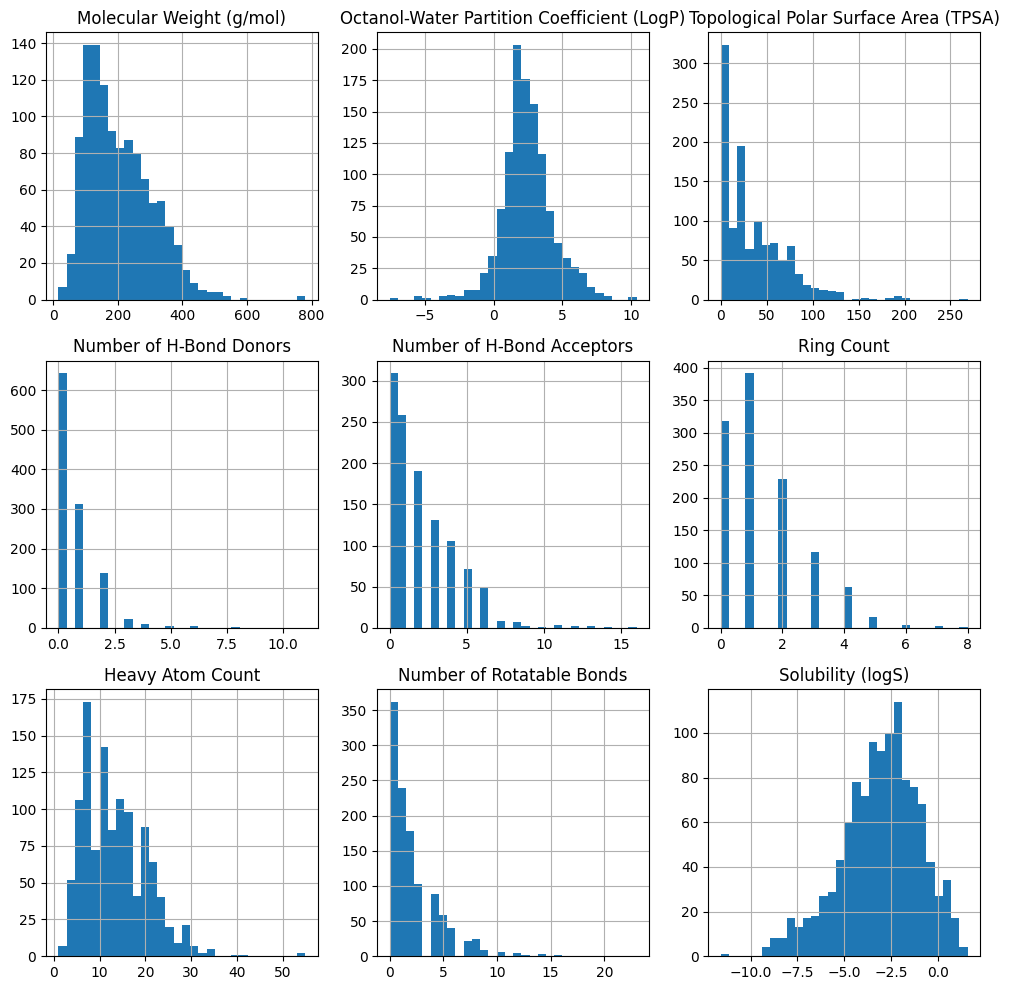

In [22]:

# TODO:
# Create histograms to visualize the distribution of molecular descriptors.
#
# Instructions:
# - Remove the 'smiles' column before plotting (it is not numeric).
# - Plot histograms for all remaining columns in the DataFrame.
# - Use a reasonable figure size and number of bins.
#
# Hints:
# - Pandas DataFrames have a built-in `.hist()` method.
# - You can customize figure size, bins, and visual style.

# YOUR CODE HERE

mol_descriptor_df1=mol_descriptor_df.drop(columns=['smiles'])
mol_descriptor_df1.hist(figsize=(10, 10), bins=30)
plt.tight_layout()
plt.show()

Some molecular descriptors are related to others.Pairplot allows us to visualize the relationships between different molecular descriptors and solubility.
This tool is useful for identifying patterns, correlations, and potential trends in the data,
which can help us better understand molecular properties of our dataset.

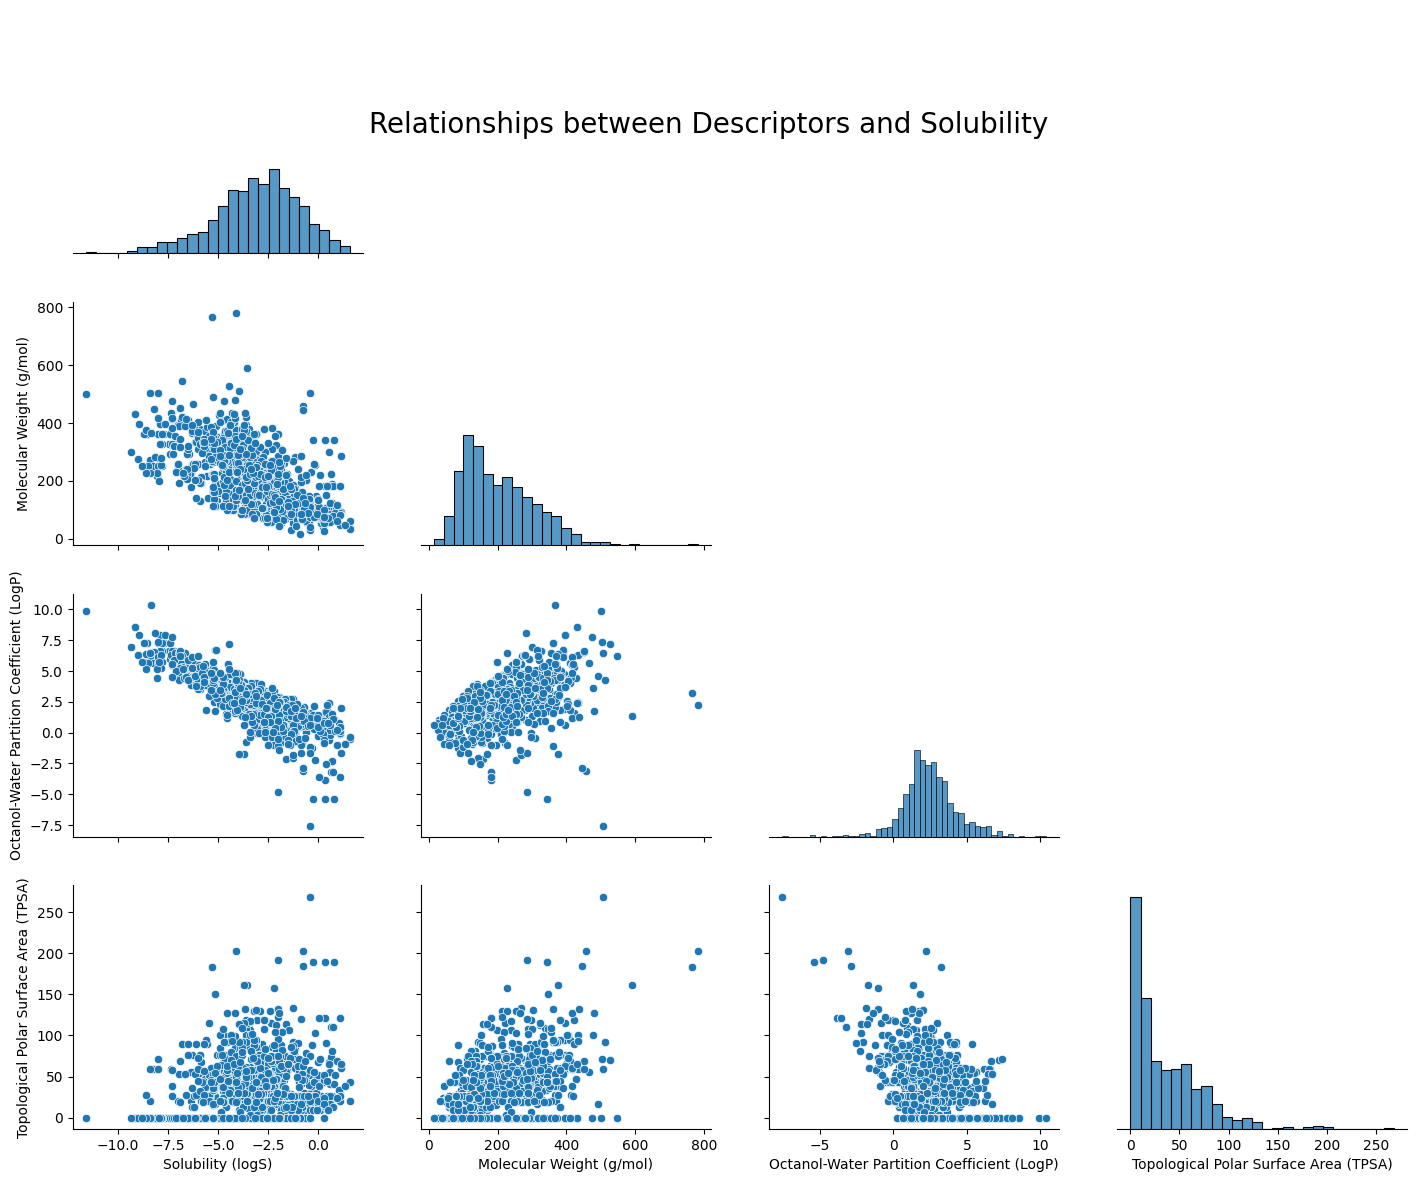

In [23]:
# Create pairplot with adjusted spacing
sns.pairplot(
    mol_descriptor_df[['Solubility (logS)', 'Molecular Weight (g/mol)',
                      'Octanol-Water Partition Coefficient (LogP)',
                      'Topological Polar Surface Area (TPSA)']],
    corner=True,
    height=3,  # Increase individual plot size
    aspect=1.2,  # Adjust aspect ratio
)

# Adjust layout
plt.subplots_adjust(
    hspace=0.2,  # Increase vertical spacing between subplots
    wspace=0.2   # Increase horizontal spacing between subplots
)

# Add title with adjusted position
plt.suptitle("Relationships between Descriptors and Solubility",
            fontsize=20,
            y=0.9)  # Move title up slightly

plt.show()


In a pairplot, it can be challenging to observe relationships when we have many variables. To simplify this, we can also create a correlation matrix.


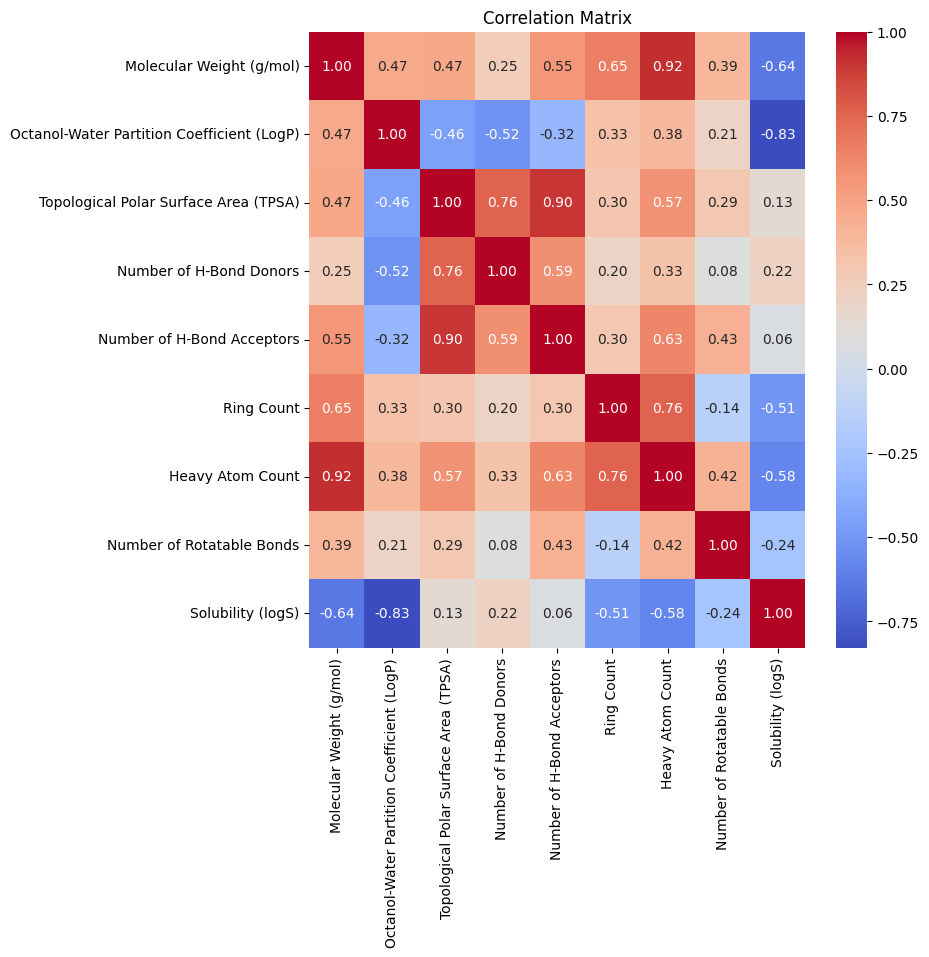

In [25]:
import numpy as np
numeric_df = mol_descriptor_df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


Let´s check the relevance molecular descriptors with Solubility

| Molecular Property                              | Correlation with logS | Interpretation / Relevance                                                                    |
|-------------------------------------------------|------------------------|-----------------------------------------------------------------------------------------------|
| Octanol-Water Partition Coefficient (LogP)      | **-0.83**              | More lipophilic molecules (higher LogP) tend to be less soluble in water.                    |
| Molecular Weight (g/mol)                        | **-0.64**              | Larger or heavier molecules are generally less water-soluble.                                |
| Heavy Atom Count                                | **-0.58**              | Molecules with more heavy atoms tend to be less soluble.                                     |
| Ring Count                                      | **-0.51**              | Molecules with more ring structures are often less soluble.                                  |
| Number of Rotatable Bonds                       | -0.24                  | Increased flexibility might reduce solubility in this dataset.                               |
| Number of H-Bond Donors                         | 0.22                   | More hydrogen bond donors can slightly increase solubility.                                  |
| Topological Polar Surface Area (TPSA)           | 0.13                   | Polar surface area may improve solubility, but has low correlation here.                    |
| Number of H-Bond Acceptors                      | 0.07                   | Very weak influence on solubility in this dataset.                                            |

📌 Conclusion

The molecular properties most strongly (negatively) correlated with solubility are:

- LogP (lipophilicity)
- Molecular Weight
- Heavy Atom Count
- Ring Count

These features stand out as the most predictive variables for solubility in this dataset, and are key candidates for use in predictive models or molecular design pipelines.


That's a lot of features, isn't it? How can we pass all this information to the deep learning model? In the field of cheminformatics, there are already libraries that help us create **embeddings** that encapsulate this information. For this, we will use **DeepChem**.

A **Featurizer** is a piece of code that transforms raw input data into a processed form suitable for machine learning.


In [26]:
from deepchem.feat import RDKitDescriptors


smiles_mols = df['SMILES'].values
solubility = df['measured log(solubility:mol/L)'].values

# TODO:
# Initialize an RDKit descriptor featurizer from DeepChem and generate molecular features.
#
# Instructions:
# - Create an instance of `RDKitDescriptors`.
# - Use it to featurize the SMILES strings.
# - Store the result in a variable called `mol_features`.
#
# Hints:
# - Use the `.featurize()` method.

# YOUR CODE HERE
featurizer = RDKitDescriptors()
mol_features = featurizer.featurize(smiles_mols)

/usr/local/lib/python3.13/dist-packages/deepchem/feat/smiles_tokenizer.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [27]:
print("Tipo:", type(mol_features))
print("Shape:", mol_features.shape)
print("Número de moléculas:", mol_features.shape[0])
print("Número de descriptores:", mol_features.shape[1])

Tipo: <class 'numpy.ndarray'>
Shape: (1144, 217)
Número de moléculas: 1144
Número de descriptores: 217


In [29]:
print(f"Number of molecules: {mol_features.shape[1]}")
mol_features = mol_features[:, ~np.isnan(mol_features).any(axis=0)]
print(f"Number of molecular descriptors without invalid values: {mol_features.shape[1]}")

Number of molecules: 217
Number of molecular descriptors without invalid values: 217


In [32]:
mol_features

array([[ 5.11651235,  5.11651235,  0.03935185, ...,  0.        ,
         0.        ,  0.        ],
       [ 5.06095679,  5.06095679,  1.08333333, ...,  0.        ,
         0.        ,  0.        ],
       [ 5.11419753,  5.11419753,  0.67283951, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [12.41230678, 12.41230678,  0.06406326, ...,  0.        ,
         0.        ,  0.        ],
       [12.38      , 12.38      ,  0.23511291, ...,  0.        ,
         0.        ,  0.        ],
       [10.8704743 , 10.8704743 ,  0.43981481, ...,  0.        ,
         0.        ,  0.        ]])

Now check the data we will work with: solubility and embeding of molecular descriptors

In [33]:
df['molecular features'] = list(mol_features)
df.drop(columns=['mols','SMILES'], inplace=True)
df.head()

,measured log(solubility:mol/L),molecular features
0,-2.18,"[5.116512345679012, 5.116512345679012, 0.03935..."
1,-2.00,"[5.0609567901234565, 5.0609567901234565, 1.083..."
2,-1.74,"[5.114197530864197, 5.114197530864197, 0.67283..."
3,-1.48,"[5.095679012345679, 5.095679012345679, 0.30864..."
4,-3.04,"[11.544753086419753, 11.544753086419753, 3.685..."


## Data Splitting
When developing Deep Learning models, it's crucial to properly split our data to ensure robust evaluation and prevent overfitting. The data is divided into three distinct sets:

### Train/Validation/Test Split
We split our data into three sets with the following distribution:

- **Training Set (80%)**
  - Used to train the model
  - The model learns patterns from this data
  - Weights and biases are adjusted based on this set

- **Validation Set (10%)**
  - Used to tune hyperparameters
  - Helps detect overfitting during training
  - Not used for training, only for evaluation
  - Guides model selection and hyperparameter optimization

- **Test Set (10%)**
  - Used only for final evaluation
  - Never seen during training or tuning
  - Provides unbiased estimate of model performance
  - Simulates real-world performance

### Why Split the Data?
1. **Prevent Overfitting**
   - Keeping test data separate ensures we don't tune our model to specific examples
   - Helps evaluate true generalization ability

2. **Proper Evaluation**
   - Test set provides unbiased performance metrics
   - Validation set helps optimize model without contaminating test data

3. **Model Selection**
   - Validation performance guides architecture and hyperparameter choices
   - Helps choose between different model variants

![Train-Validation-Test Split](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

This splitting strategy is fundamental for developing robust Deep Learning models that can generalize well to new, unseen data.

In [36]:
from deepchem.splits import RandomSplitter
from deepchem.data import NumpyDataset

# Prepare the data
X = np.array([x for x in df['molecular features']])  # Features
y = df['measured log(solubility:mol/L)'].values.reshape(-1, 1)  # Target

# Create the DeepChem dataset
dataset = NumpyDataset(X=X, y=y)

# Use the splitter
# 80% train, 10% validation, 10% test
splitter = RandomSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1,
    seed=0
)

# Check the dimensions
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(valid_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 915
Validation set size: 114
Test set size: 115


# 3. Neural Network Architecture

### Understanding Neural Network Layers

A neural network consists of three main types of layers:

1. **Input Layer**
   - First layer in the network
   - Receives raw features (in our case, molecular descriptors)
   - Number of neurons equals number of input features
   - No computation performed, just passes data forward

2. **Hidden Layers**
   - Layers between input and output
   - Process and transform the data
   - Apply weights, biases, and activation functions
   - Can be multiple layers deep
   - Each neuron connects to all neurons in next layer

3. **Output Layer**
   - Final layer of the network
   - Produces the prediction (in our case, solubility value)
   - Number of neurons matches prediction task
   - One neuron for regression (our case)

<div align="center">
<img src="https://github.com/schwallergroup/ai4chem_course/blob/main/notebooks/03%20-%20Intro%20to%20Deep%20Learning/img/nn_image.png?raw=1" width="500"/>
</div>

### Understanding Layer Depth in Neural Networks
The number of hidden layers significantly impacts a neural network's ability to learn complex, non-linear patterns:

1. **Single Layer Networks**
   - Can only learn linear relationships
   - Limited capacity for complex patterns
   - Example: `y = ax + b`

2. **Two Layer Networks**
   - Can approximate any continuous function
   - Good for simple non-linear patterns
   - Example: Can learn basic curves and patterns

3. **Deep Networks (3+ layers)**
   - Can learn hierarchical features
   - Better at capturing complex non-linear relationships
   - More efficient parameter usage for complex tasks

<div align="center">
<img src="https://vitalflux.com/wp-content/uploads/2022/04/Linearly-vs-Not-linearly-separable-datasets-768x285.png" width="600"/>
</div>

### Our Implementation
We'll experiment with different architectures using grid search:

```python
param_grid = {
    'num_layers': [1, 2, 3],     
    'hidden_size': [256, 512],   
    'learning_rate': [0.001, 0.0001],
    'batch_size': [32, 64]
}
```

### Expected Impact:
- **More Layers**: Better capture of complex molecular relationships
- **More Neurons**: Increased model capacity but risk of overfitting
- **Trade-off**: Deeper networks might be harder to train but could learn better representations

### Why This Matters for Solubility Prediction
Molecular solubility depends on multiple non-linear interactions:
- Hydrogen bonding
- Van der Waals forces
- Conformational changes
- Complex structure-property relationships

A deeper network might better capture these intricate relationships between molecular features and solubility.

## 3.1 Creating a Deep Learning Model

Modern deep learning frameworks like [PyTorch Lightning](https://pytorch-lightning.readthedocs.io/en/stable/index.html) use object-oriented programming to make model creation intuitive and flexible. Before we build our neural network, let's understand the fundamental concept of classes.

### Understanding Classes in Python

A class is like a blueprint that defines:
- What properties (attributes) an object has
- What actions (methods) it can perform

Think of it this way:
- A class is to an object what a blueprint is to a house
- Many houses can be built from the same blueprint
- Each house (instance) can have different:
  - Number of rooms
  - Size
  - Color
  - Utilities

Here's a simple example:

```python
class House:
    def __init__(self, rooms, size, style):
        # Attributes
        self.rooms = rooms    # Like layers in our network
        self.size = size      # Like neurons in each layer
        self.style = style    # Like activation function
        
    def describe(self):
        # Method - what the house can do
        print(f"This {self.style} house has {self.rooms} rooms and is {self.size} sqft")
```

We can create multiple houses (instances) from this class:
```python
    modern_house = House(rooms=3, size=2000, style="modern")
    colonial_house = House(rooms=5, size=3000, style="colonial")

    modern_house.describe()
```
The output should be something like this: ```"This modern house has 3 rooms and is 2000 sqft"```


### From Houses to Neural Networks
Now let's define a NeuralNetwork class.This same concept applies to creating neural networks, a neural network class defines its structure and behavior. Here's how the analogy translates:

| House Blueprint | Neural Network |
|----------------|----------------|
| Rooms | Layers |
| Size | Number of Neurons |
| Style | Activation Functions |
| Description | Predictions |

#### Neural Network Components


### 1. Attributes
- **Learning Rate (`lr`)**:
  - Controls weight update magnitude
  - Default: 1e-3

- **Datasets**:
  - `train_dataset`: Training data
  - `valid_dataset`: Validation data  
  - `test_dataset`: Test data

- **Batch Size**:
  - Number of samples per update
  - Default: 254

- **Loss Tracking**:
  - `train_losses`: Average loss per epoch
  - `val_losses`: Validation loss per epoch
  - `train_epoch_losses`: Individual batch losses
  - `val_epoch_losses`: Individual validation losses

- **Model Architecture**:
  - Input layer: `input_sz` features
  - Hidden layers: `num_layers` with `hidden_sz` neurons
  - Output layer: Single neuron (regression)
  - Activation: ReLU between layers

### 2. Methods
- **Forward Pass (`forward`)**:
  - Takes input tensor x
  - Passes through model layers
  - Returns flattened predictions

- **Training (`training_step`)**:
  - Processes batch of data
  - Computes predictions and loss
  - Logs training metrics
  - Stores loss for learning curves

- **Validation (`validation_step`)**:
  - Evaluates model on validation data
  - Computes validation loss
  - No weight updates
  - Tracks performance

- **Testing (`test_step`)**:
  - Final model evaluation
  - Computes test MSE
  - No weight updates

- **Optimization (`configure_optimizers`)**:
  - Uses Adam optimizer
  - Configurable learning rate

- **Data Loading**:
  - `train_dataloader`: Training data with shuffling
  - `val_dataloader`: Validation data, no shuffle
  - `test_dataloader`: Test data, no shuffle

In [37]:
import os
import torch
import wandb
from torch import nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from pytorch_lightning.loggers import WandbLogger
from torch.utils.data import TensorDataset

In [41]:
class NeuralNetwork(pl.LightningModule):
    """
    Neural network model for molecular solubility prediction
    using PyTorch Lightning.

    Architecture:
        - Input Layer: molecular descriptors
        - Hidden Layers: num_layers layers with hidden_sz neurons
        - ReLU activation
        - Output Layer: one neuron for solubility prediction
    """

    def __init__(
        self,
        input_sz,
        hidden_sz,
        num_layers,
        train_dataset,
        valid_dataset,
        test_dataset,
        batch_size=254,
        lr=1e-3
    ):

        super().__init__()

        # ============================================================
        # HYPERPARAMETERS AND DATASETS
        # ============================================================

        self.lr = lr
        self.train_dataset = train_dataset
        self.valid_dataset = valid_dataset
        self.test_dataset = test_dataset
        self.batch_size = batch_size

        # ============================================================
        # LISTS TO STORE LOSSES
        # ============================================================

        self.train_losses = []
        self.val_losses = []

        self.train_epoch_losses = []
        self.val_epoch_losses = []

        # ============================================================
        # NEURAL NETWORK ARCHITECTURE
        # ============================================================

        layers = []

        # ------------------------------------------------------------
        # First hidden layer
        # input_sz -> hidden_sz
        # ------------------------------------------------------------

        layers.append(
            nn.Linear(input_sz, hidden_sz)
        )

        layers.append(
            nn.ReLU()
        )

        # ------------------------------------------------------------
        # Additional hidden layers
        # hidden_sz -> hidden_sz
        # ------------------------------------------------------------

        for _ in range(num_layers - 1):

            layers.append(
                nn.Linear(hidden_sz, hidden_sz)
            )

            layers.append(
                nn.ReLU()
            )

        # ------------------------------------------------------------
        # Output layer
        # hidden_sz -> 1
        # ------------------------------------------------------------

        layers.append(
            nn.Linear(hidden_sz, 1)
        )

        # Create sequential neural network
        self.model = nn.Sequential(*layers)

    # ================================================================
    # FORWARD PASS
    # ================================================================

    def forward(self, x):
        """
        Forward pass through the neural network.
        """

        return self.model(x).flatten()

    # ================================================================
    # TRAINING STEP
    # ================================================================

    def training_step(self, batch, batch_idx):
        """
        Training step for one batch.
        """

        # Features and targets
        x, y = batch

        # Forward pass
        z = self.model(x)

        # Mean Squared Error
        loss = F.mse_loss(z, y)

        # Log training loss
        self.log(
            "Train loss",
            loss,
            on_epoch=True,
            prog_bar=True
        )

        # Store loss for learning curve
        self.train_epoch_losses.append(
            loss.detach()
        )

        return loss

    # ================================================================
    # VALIDATION STEP
    # ================================================================

    def validation_step(self, batch, batch_idx):
        """
        Validation step for one batch.
        """

        x, y = batch

        # Prediction
        z = self.model(x)

        # Validation loss
        loss = F.mse_loss(z, y)

        self.log(
            "Valid MSE",
            loss,
            on_epoch=True,
            prog_bar=True
        )

        # Store validation loss
        self.val_epoch_losses.append(
            loss.detach()
        )

        return loss

    # ================================================================
    # TEST STEP
    # ================================================================

    def test_step(self, batch, batch_idx):
        """
        Test step.
        """

        x, y = batch

        # Prediction
        z = self.model(x)

        # Test MSE
        loss = F.mse_loss(z, y)

        self.log(
            "Test MSE",
            loss
        )

    # ================================================================
    # OPTIMIZER
    # ================================================================

    def configure_optimizers(self):
        """
        Adam optimizer.
        """

        return torch.optim.Adam(
            self.parameters(),
            lr=self.lr
        )

    # ================================================================
    # TRAIN DATALOADER
    # ================================================================

    def train_dataloader(self):
        """
        Training DataLoader.
        """

        X = torch.FloatTensor(
            self.train_dataset.X
        )

        y = torch.FloatTensor(
            self.train_dataset.y
        )

        return DataLoader(
            TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=True
        )

    # ================================================================
    # VALIDATION DATALOADER
    # ================================================================

    def val_dataloader(self):
        """
        Validation DataLoader.
        """

        X = torch.FloatTensor(
            self.valid_dataset.X
        )

        y = torch.FloatTensor(
            self.valid_dataset.y
        )

        return DataLoader(
            TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=True
        )

    # ================================================================
    # TEST DATALOADER
    # ================================================================

    def test_dataloader(self):
        """
        Test DataLoader.
        """

        X = torch.FloatTensor(
            self.test_dataset.X
        )

        y = torch.FloatTensor(
            self.test_dataset.y
        )

        return DataLoader(
            TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=True
        )

    # ================================================================
    # END OF TRAINING EPOCH
    # ================================================================

    def on_train_epoch_end(self):
        """
        Calculate average training loss for each epoch.
        """

        avg_loss = torch.stack(
            self.train_epoch_losses
        ).mean()

        self.train_losses.append(
            avg_loss.item()
        )

        self.train_epoch_losses.clear()

    # ================================================================
    # END OF VALIDATION EPOCH
    # ================================================================

    def on_validation_epoch_end(self):
        """
        Calculate average validation loss for each epoch.
        """

        avg_loss = torch.stack(
            self.val_epoch_losses
        ).mean()

        self.val_losses.append(
            avg_loss.item()
        )

        self.val_epoch_losses.clear()

## PyTorch Lightning Trainer

The Trainer is a high-level interface that handles:
1. Training loop management
2. Validation checks
3. Early stopping
4. GPU acceleration
5. Logging and monitoring

Let's implement grid search to find optimal hyperparameters:

### Hyperparameters Explained

1. **Learning Rate (lr)**:
   - Controls how much we adjust weights in each step
   - Too high: unstable training
   - Too low: slow training

2. **Batch Size**:
   - Number of samples processed before weight update
   - Larger: more stable, but needs more memory
   - Smaller: more noise, but can help escape local minima

3. **Hidden Size**:
   - Number of neurons in hidden layers
   - Larger: more capacity to learn, but risk of overfitting
   - Smaller: may underfit if too small

4. **Number of Epochs**:
   - How many times we go through the entire dataset
   - Too few: underfitting
   - Too many: risk of overfitting

### Root Mean Square Error (RMSE)
RMSE is our main evaluation metric:
- Calculated as: √(mean((predicted - actual)²))
- Gives more weight to larger errors
- In same units as our target (log mol/L)


In [42]:
# ============================================================
# GRID SEARCH - DEEP LEARNING PARA PREDICCIÓN DE SOLUBILIDAD
# ============================================================

import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl


# ============================================================
# FUNCIÓN GRID SEARCH
# ============================================================

def grid_search_cv(param_grid):

    # Mejor RMSE encontrado hasta el momento
    best_rmse = float('inf')

    # Mejores hiperparámetros
    best_params = None

    # Lista para almacenar todos los resultados
    results = []

    # ========================================================
    # RECORRER TODAS LAS COMBINACIONES
    # ========================================================

    for lr in param_grid['learning_rate']:

        for hidden_size in param_grid['hidden_size']:

            for batch_size in param_grid['batch_size']:

                for num_layers in param_grid['num_layers']:

                    print("\n" + "=" * 70)

                    print(
                        f"Testing: "
                        f"lr={lr}, "
                        f"hidden_size={hidden_size}, "
                        f"batch_size={batch_size}, "
                        f"num_layers={num_layers}"
                    )

                    print("=" * 70)

                    # ====================================================
                    # CREAR MODELO
                    # ====================================================

                    model = NeuralNetwork(

                        # Número de descriptores moleculares
                        input_sz=train_dataset.X.shape[1],

                        # Número de neuronas por capa oculta
                        hidden_sz=hidden_size,

                        # Número de capas ocultas
                        num_layers=num_layers,

                        # Datasets
                        train_dataset=train_dataset,
                        valid_dataset=valid_dataset,
                        test_dataset=test_dataset,

                        # Hiperparámetros
                        lr=lr,
                        batch_size=batch_size
                    )

                    # ====================================================
                    # CREAR TRAINER
                    # ====================================================

                    trainer = pl.Trainer(
                        max_epochs=50,
                        logger=False,
                        enable_progress_bar=True,
                        enable_checkpointing=False
                    )

                    # ====================================================
                    # ENTRENAR MODELO
                    # ====================================================

                    trainer.fit(model)

                    # ====================================================
                    # EVALUAR MODELO
                    # ====================================================

                    test_results = trainer.test(
                        model=model,
                        verbose=False
                    )[0]

                    # Extraer MSE
                    test_mse = test_results["Test MSE"]

                    # Calcular RMSE
                    current_rmse = np.sqrt(test_mse)

                    # ====================================================
                    # GUARDAR RESULTADOS
                    # ====================================================

                    results.append({

                        'learning_rate': lr,
                        'hidden_size': hidden_size,
                        'batch_size': batch_size,
                        'num_layers': num_layers,
                        'Test_MSE': test_mse,
                        'RMSE': current_rmse
                    })

                    print(
                        f"\nRMSE obtenido: {current_rmse:.6f}"
                    )

                    # ====================================================
                    # COMPROBAR SI ES EL MEJOR MODELO
                    # ====================================================

                    if current_rmse < best_rmse:

                        best_rmse = current_rmse

                        best_params = {

                            'learning_rate': lr,
                            'hidden_size': hidden_size,
                            'batch_size': batch_size,
                            'num_layers': num_layers
                        }

                        print("\n>>> NUEVO MEJOR MODELO <<<")
                        print(
                            f"RMSE = {best_rmse:.6f}"
                        )

    # ========================================================
    # CONVERTIR RESULTADOS A DATAFRAME
    # ========================================================

    results_df = pd.DataFrame(results)

    return results_df, best_params, best_rmse


# ============================================================
# HIPERPARÁMETROS A EXPLORAR
# ============================================================

param_grid = {

    # Learning rate
    'learning_rate': [
        0.001,
        0.0001
    ],

    # Número de neuronas en las capas ocultas
    'hidden_size': [
        256,
        512
    ],

    # Tamaño de batch
    'batch_size': [
        32,
        64
    ],

    # Número de capas ocultas
    'num_layers': [
        1,
        2,
        3
    ]
}


# ============================================================
# INFORMACIÓN DEL GRID SEARCH
# ============================================================

n_combinations = (
    len(param_grid['learning_rate'])
    * len(param_grid['hidden_size'])
    * len(param_grid['batch_size'])
    * len(param_grid['num_layers'])
)

print("=" * 70)
print("GRID SEARCH - MOLECULAR SOLUBILITY")
print("=" * 70)

print(
    f"Input features      : {train_dataset.X.shape[1]}"
)

print(
    f"Training samples    : {len(train_dataset)}"
)

print(
    f"Validation samples  : {len(valid_dataset)}"
)

print(
    f"Test samples        : {len(test_dataset)}"
)

print(
    f"Combinations        : {n_combinations}"
)

print(
    f"Maximum epochs      : 50"
)

print("=" * 70)


# ============================================================
# EJECUTAR GRID SEARCH
# ============================================================

results_df, best_params, best_rmse = grid_search_cv(
    param_grid
)


# ============================================================
# ORDENAR RESULTADOS DE MEJOR A PEOR
# ============================================================

results_df = results_df.sort_values(
    by='RMSE',
    ascending=True
).reset_index(drop=True)


# ============================================================
# MOSTRAR TODOS LOS RESULTADOS
# ============================================================

print("\n")
print("=" * 70)
print("GRID SEARCH RESULTS")
print("=" * 70)

print(results_df.to_string(index=False))


# ============================================================
# MOSTRAR MEJOR CONFIGURACIÓN
# ============================================================

print("\n")
print("=" * 70)
print("BEST HYPERPARAMETERS")
print("=" * 70)

print(
    f"Learning rate : {best_params['learning_rate']}"
)

print(
    f"Hidden size   : {best_params['hidden_size']}"
)

print(
    f"Batch size    : {best_params['batch_size']}"
)

print(
    f"Num layers    : {best_params['num_layers']}"
)

print(
    f"Best RMSE     : {best_rmse:.6f}"
)

print("=" * 70)

GRID SEARCH - MOLECULAR SOLUBILITY
Input features      : 217
Training samples    : 915
Validation samples  : 114
Test samples        : 115
Combinations        : 24
Maximum epochs      : 50

Testing: lr=0.001, hidden_size=256, batch_size=32, num_layers=1


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │ 56.1 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 56.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 56.1 K                                                                                               
Total estimated model params size (MB): 0.224                                                                      
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Trainable params: 637 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 637 K                                                                                                
Total estimated model params size (MB): 2.550                                                                      
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


Output()


RMSE obtenido: 0.822221


GRID SEARCH RESULTS
 learning_rate  hidden_size  batch_size  num_layers  Test_MSE     RMSE
        0.0010          256          64           2  0.651011 0.806853
        0.0001          512          32           3  0.652574 0.807821
        0.0001          512          64           3  0.676047 0.822221
        0.0010          256          64           1  0.684934 0.827607
        0.0010          256          32           2  0.714758 0.845434
        0.0010          512          64           2  0.762162 0.873019
        0.0010          256          32           3  0.775461 0.880603
        0.0001          256          32           2  0.777837 0.881951
        0.0010          256          64           3  0.820676 0.905912
        0.0010          512          64           3  0.913966 0.956016
        0.0010          512          32           3  1.062467 1.030760
        0.0001          256          64           2  1.114292 1.055600
        0.0001          256   

# Reflection / Discussion:
- Which hyperparameter combination gave you the best RMSE?
- How did your choice of hyperparameter ranges affect the results?
- If you had more computational time, how would you expand your search?

# Class activity:
- Share your `param_grid` and best results with the class.
- Compare strategies: who explored wider vs. more focused ranges?

## Reflection / Discussion

### 1. Which hyperparameter combination gave you the best RMSE?

The best hyperparameter combination was:

- **Learning rate:** 0.001
- **Hidden size:** 256
- **Batch size:** 64
- **Number of hidden layers:** 2
- **Best RMSE:** 0.806853

This configuration achieved the lowest RMSE among the 24 combinations evaluated. Therefore, within the explored hyperparameter space, a network with two hidden layers and 256 neurons provided the best performance.

### 2. How did your choice of hyperparameter ranges affect the results?

The selected hyperparameter ranges allowed us to compare different learning rates, network sizes, batch sizes, and numbers of hidden layers. The results showed that increasing the complexity of the neural network did not necessarily improve its performance.

For example, using 512 neurons or three hidden layers did not consistently produce a lower RMSE. The best model used a learning rate of 0.001, indicating that this value allowed the network to learn more effectively than the smaller learning rate tested.

### 3. If you had more computational time, how would you expand your search?

With more computational time, I would explore a wider and more detailed range of hyperparameters. I would test intermediate learning rates such as 0.0005 and 0.0008, additional hidden sizes such as 128, 192, 256, and 384, and batch sizes such as 16 and 128.

I would also increase the number of training epochs and explore other techniques such as dropout, weight decay, and early stopping. Since the best model used 256 neurons and two hidden layers, a more focused search around these values could potentially improve the prediction performance.

---

## Class Activity

The hyperparameter grid used in this experiment was:

- **Learning rate:** [0.001, 0.0001]
- **Hidden size:** [256, 512]
- **Batch size:** [32, 64]
- **Number of layers:** [1, 2, 3]

This gives a total of:

$$
2 \times 2 \times 2 \times 3 = 24
$$

different neural network configurations.

The best result obtained was:

$$
\boxed{\text{RMSE} = 0.806853}
$$

with a learning rate of **0.001**, hidden size of **256**, batch size of **64**, and **2 hidden layers**.

When comparing strategies with the class, it is important to consider that a wider hyperparameter search explores more possible configurations but requires more computational time. A more focused search is faster and can be useful when previous results already indicate which region of the hyperparameter space performs better.

## Training with Best Parameters

Now let's train our final model with the best parameters found:

In [46]:
# ============================================================
# TRAIN FINAL MODEL WITH BEST PARAMETERS
# ============================================================

# Create final model with best parameters
final_model = NeuralNetwork(
    input_sz=len(train_dataset.X[1]),
    hidden_sz=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    test_dataset=test_dataset,
    lr=best_params['learning_rate'],      # CORREGIDO
    batch_size=best_params['batch_size']
)

# ============================================================
# TRAIN FINAL MODEL
# ============================================================

trainer = pl.Trainer(
    max_epochs=150,
    logger=False,
    enable_progress_bar=True
)

trainer.fit(final_model)

# ============================================================
# TEST FINAL MODEL
# ============================================================

final_results = trainer.test(
    model=final_model
)

# ============================================================
# CALCULATE FINAL RMSE
# ============================================================

final_rmse = final_results[0]["Test MSE"] ** 0.5

print(f'\nFinal Model RMSE: {final_rmse:.4f}')

print("\n✓ Training completed!")

print(f"  Learning Rate: {best_params['learning_rate']}")
print(f"  Hidden Size: {best_params['hidden_size']}")
print(f"  Batch Size: {best_params['batch_size']}")
print(f"  Num Layers: {best_params['num_layers']}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │  121 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 121 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 121 K                                                                                                
Total estimated model params size (MB): 0.487                                                                      
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=150` reached.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         Test MSE          │    1.6718977689743042     │
└───────────────────────────┴───────────────────────────┘

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.



Final Model RMSE: 1.2930

✓ Training completed!
  Learning Rate: 0.001
  Hidden Size: 256
  Batch Size: 64
  Num Layers: 2


## 5.Model Analysis

Let's analyze our model's performance through different visualizations:

### 5.1 Learning Curves
The training and validation loss curves help us understand how the model learned over time:

- **Training Loss**: Shows how well the model fits the training data
- **Validation Loss**: Indicates how well the model generalizes to unseen data

A good model should show:
- Decreasing losses over time
- Small gap between training and validation curves
- No significant oscillations
- Signs of convergence

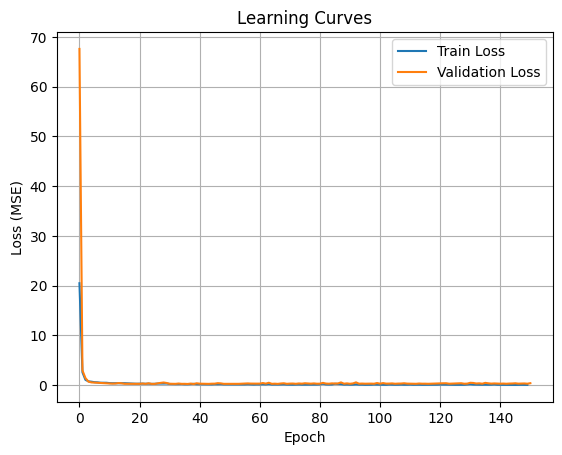

In [48]:
import matplotlib.pyplot as plt

plt.plot(final_model.train_losses, label='Train Loss')
plt.plot(final_model.val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Learning Curves')
plt.legend()
plt.grid(True)
plt.show()


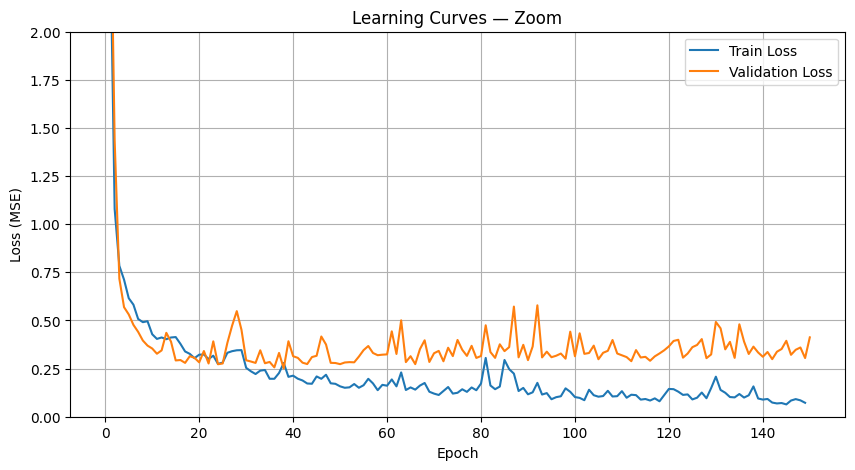

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(final_model.train_losses, label='Train Loss')
plt.plot(final_model.val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Learning Curves — Zoom')
plt.ylim(0, 2)

plt.legend()
plt.grid(True)
plt.show()

In [50]:
import numpy as np

best_epoch = np.argmin(final_model.val_losses)
best_val_loss = final_model.val_losses[best_epoch]

print(f"Best epoch: {best_epoch}")
print(f"Minimum validation MSE: {best_val_loss:.6f}")

Best epoch: 38
Minimum validation MSE: 0.250707


### Learning Curves Analysis

The learning curves show that both training and validation losses decrease rapidly during the first epochs, indicating that the neural network is learning meaningful patterns from the molecular descriptors.

The minimum validation loss was obtained at **epoch 38**, with:

$$
MSE_{val} = 0.250707
$$

After this point, the training loss continues to decrease, while the validation loss fluctuates and does not show a consistent improvement. This behavior suggests **overfitting**, since the model continues improving its fit to the training data without improving its performance on unseen validation data.

Therefore, training for the full 150 epochs was not necessarily optimal. An early-stopping strategy could stop training near the minimum validation loss and preserve the model with the best generalization performance.

### 5.2 Prediction Performance Analysis

Let's evaluate how well our model performs on the test set by comparing predicted vs actual solubility values. We'll analyze:

1. **Scatter Plot**:
   - Visual representation of predictions against actual values
   - Perfect predictions would lie on the diagonal line
   - Points above the line indicate overestimation
   - Points below the line indicate underestimation


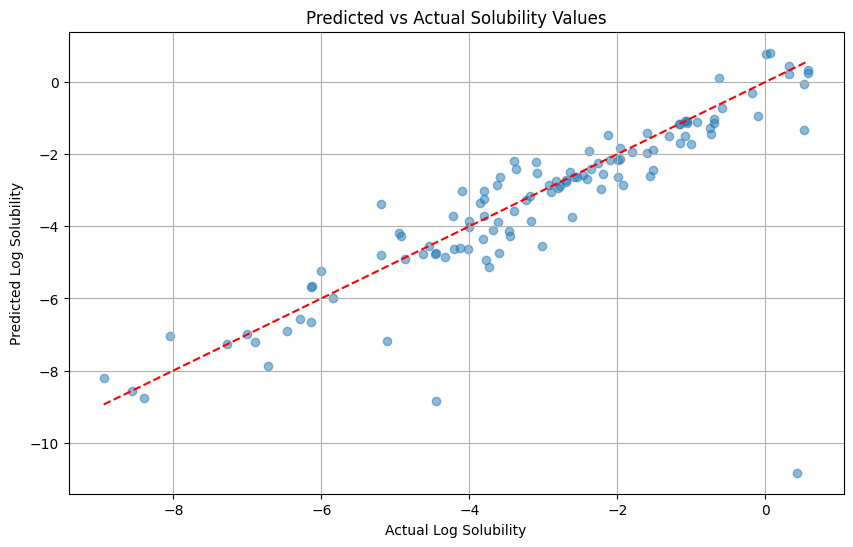

In [51]:
# Get predictions on test set
test_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(test_dataset.X),
        torch.FloatTensor(test_dataset.y)
    ),
    batch_size=len(test_dataset),
    shuffle=False
)

# ============================================================
# GENERATE PREDICTIONS ON TEST SET
# ============================================================

# Convert test features to tensor
X_test_tensor = torch.FloatTensor(test_dataset.X)

# Convert test targets to tensor
y_test_tensor = torch.FloatTensor(test_dataset.y)

# Set model to evaluation mode
final_model.eval()

# Generate predictions without calculating gradients
with torch.no_grad():
    predictions = final_model(X_test_tensor)

# Convert predictions to NumPy array
predictions = predictions.detach().numpy()

# ============================================================
# PLOT PREDICTIONS VS ACTUAL VALUES
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    test_dataset.y.flatten(),
    predictions,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [min(test_dataset.y), max(test_dataset.y)],
    [min(test_dataset.y), max(test_dataset.y)],
    'r--'
)

plt.xlabel('Actual Log Solubility')
plt.ylabel('Predicted Log Solubility')
plt.title('Predicted vs Actual Solubility Values')

plt.grid(True)
plt.show()

### Prediction Performance Analysis

The predicted vs. actual solubility plot shows that most predictions follow the general trend of the ideal diagonal line, indicating that the neural network learned a meaningful relationship between the molecular descriptors and solubility.

However, some points deviate considerably from the diagonal, indicating large prediction errors for specific molecules. One particularly large outlier can be observed for a molecule with an actual log-solubility close to zero but a predicted value near -11.

These large errors can strongly affect the RMSE because this metric squares the individual prediction errors before averaging them. Therefore, a small number of extreme errors can substantially increase the overall test RMSE.

Points above the diagonal correspond to overestimation of solubility, while points below the diagonal correspond to underestimation. Overall, the model captures the general relationship between molecular descriptors and solubility, but its performance is affected by several large prediction errors.

2. **Error Statistics**:
   - Mean Error: Shows systematic bias in predictions
   - Standard Deviation: Indicates prediction consistency
   - Median Error: Robust measure of central tendency

In [54]:

# Calculate error statistics
errors = predictions - test_dataset.y
print('\nError Statistics:')
print(f'Mean Error: {np.mean(errors):.4f}')
print(f'Standard Deviation of Error: {np.std(errors):.4f}')
print(f'Median Error: {np.median(errors):.4f}')


Error Statistics:
Mean Error: -0.2492
Standard Deviation of Error: 3.0917
Median Error: -0.1864


### Error Statistics Analysis

The error statistics provide additional information about the prediction performance of the model:

- **Mean Error:** -0.2492
- **Standard Deviation of Error:** 3.0917
- **Median Error:** -0.1864

The negative mean error indicates a slight overall tendency of the model to **underestimate solubility**. However, both the mean and median errors are relatively close to zero, suggesting that the model does not show a strong systematic bias.

The standard deviation of the errors is considerably larger, indicating substantial variability in the prediction errors. This is consistent with the predicted vs. actual plot, where most predictions follow the general trend but some molecules show large deviations from the ideal prediction line.

Overall, the main limitation appears to be the **dispersion and presence of large individual errors**, rather than a strong systematic tendency to overestimate or underestimate solubility.

### 5.1. Error Analysis Based on Molecular Descriptors

#### What do we want to understand?

We aim to investigate whether the model systematically struggles with certain types of molecules (e.g., highly polar or highly lipophilic) by analyzing the relationship between prediction errors and molecular descriptors.


Original dataset shape: (1144, 4)

Columns:
['Compound ID', 'measured log(solubility:mol/L)', 'ESOL predicted log(solubility:mol/L)', 'SMILES']

Invalid molecules: 0

Molecular descriptor dataset:


,SMILES,measured log(solubility:mol/L),MolWt,LogP,TPSA,NumHDonors,NumHAcceptors,RingCount,HeavyAtomCount,RotatableBonds
0,ClCC(Cl)(Cl)Cl,-2.18,167.850,2.5954,0.0,0,0,0,6,0
1,CC(Cl)(Cl)Cl,-2.00,133.405,2.3765,0.0,0,0,0,5,0
2,ClC(Cl)C(Cl)Cl,-1.74,167.850,2.5938,0.0,0,0,0,6,1
3,ClCC(Cl)Cl,-1.48,133.405,2.0289,0.0,0,0,0,5,1
4,FC(F)(Cl)C(F)(Cl)Cl,-3.04,187.375,2.9189,0.0,0,0,0,8,1



Descriptor dataset shape:
(1144, 10)

Number of molecular features: 217

Reconstructed split:
Training samples: 915
Validation samples: 114
Test samples: 115

Test descriptor dataframe shape:
(115, 10)

Checking dimensions:
Test molecules : 115
Predictions    : 115
Actual values  : 115
Errors         : 115

TEST SET ALIGNMENT CHECK
Matching samples: 115 / 115
All samples match: True

Final dataframe for molecular descriptor error analysis:


,SMILES,measured log(solubility:mol/L),MolWt,LogP,TPSA,NumHDonors,NumHAcceptors,RingCount,HeavyAtomCount,RotatableBonds,Actual_logS,Predicted_logS,Error,Absolute_Error
0,CC34CCC1C(CCc2cc(O)ccc12)C3CC(O)C4O,-4.955,288.387,2.58000,60.69,3,3,4,21,0,-4.955,-4.196723,0.758277,0.758277
1,CC(C)C(C)O,-0.180,88.150,1.02320,20.23,1,1,0,6,1,-0.180,-0.294121,-0.114121,0.114121
2,CC(OC(=O)Nc1cccc(Cl)c1)C#C,-2.617,223.659,2.91020,38.33,1,2,1,15,2,-2.617,-3.735398,-1.118398,1.118398
3,OC(CC(c1ccccc1)c3c(O)c2ccccc2oc3=O)c4ccc(cc4)c...,-4.445,527.414,7.18370,70.67,2,4,5,35,6,-4.445,-8.831693,-4.386693,4.386693
4,Oc1cccc(Cl)c1,-0.700,128.558,2.04560,20.23,1,1,1,8,0,-0.700,-1.134622,-0.434622,0.434622
5,COC(C)(C)CCCC(C)CC=CC(C)=CC(=O)OC(C)C,-5.190,310.478,5.06200,35.53,0,3,0,22,10,-5.190,-4.782347,0.407653,0.407653
6,Cc1cc(C)cc(C)c1,-3.400,120.195,2.61186,0.00,0,0,1,9,0,-3.400,-3.576540,-0.176540,0.176540
7,Oc1ccc(Br)cc1,-1.090,173.009,2.15470,20.23,1,1,1,8,0,-1.090,-1.486390,-0.396390,0.396390
8,COc2c1occc1c(OC)c3c(=O)cc(C)oc23,-3.021,260.245,2.86482,61.81,0,5,3,19,2,-3.021,-4.550423,-1.529423,1.529423
9,Clc1cccc(Cl)c1Cl,-4.000,181.449,3.64680,0.00,0,0,1,9,0,-4.000,-4.007452,-0.007452,0.007452



ERROR STATISTICS
Mean Error: -0.2492
Standard Deviation of Error: 1.2688
Median Error: -0.1299
RMSE: 1.2930


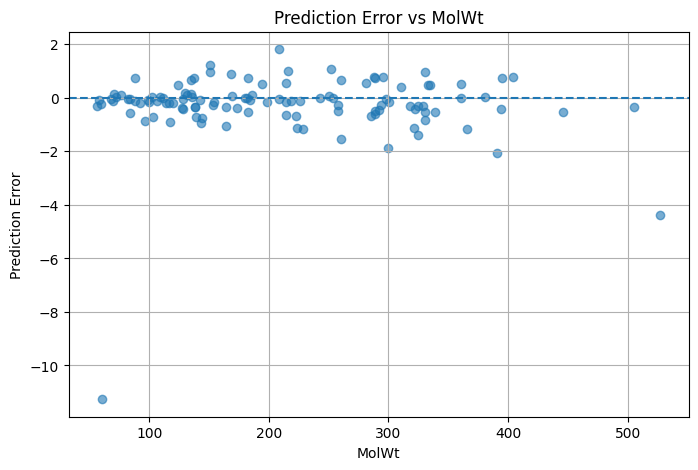

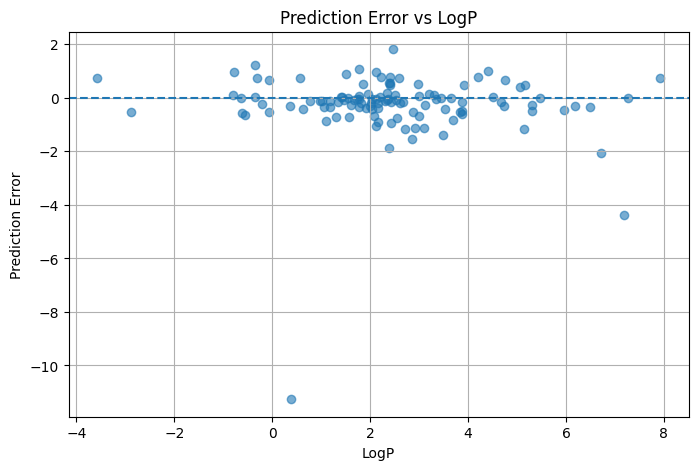

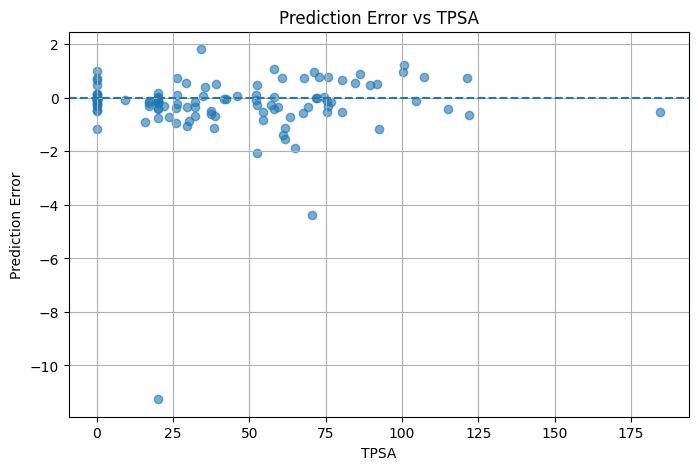

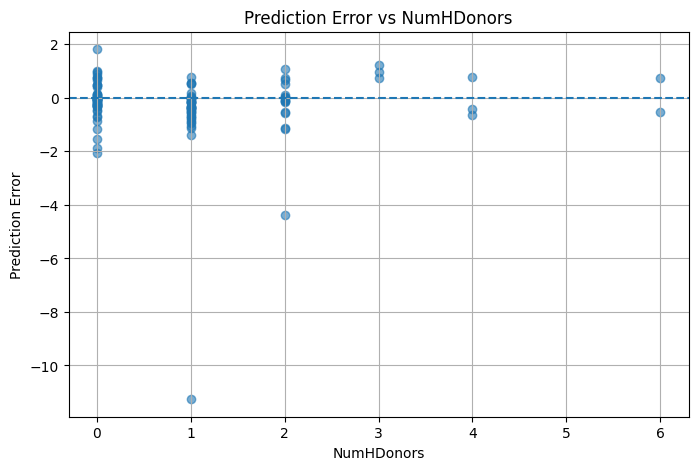

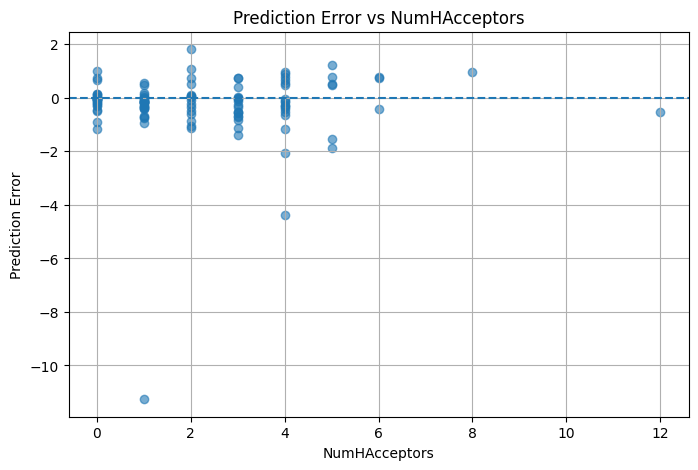

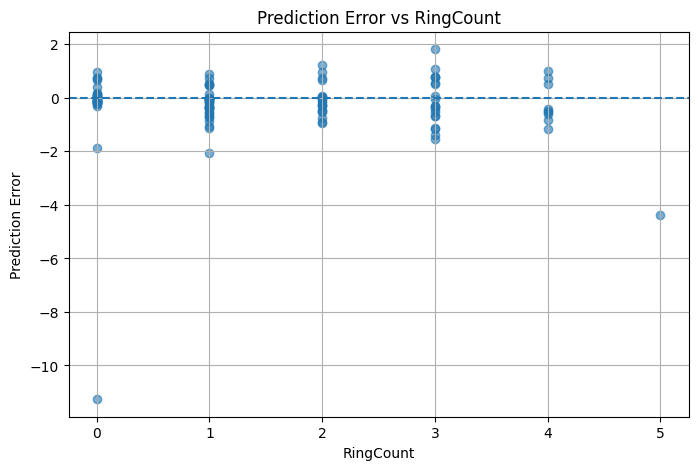

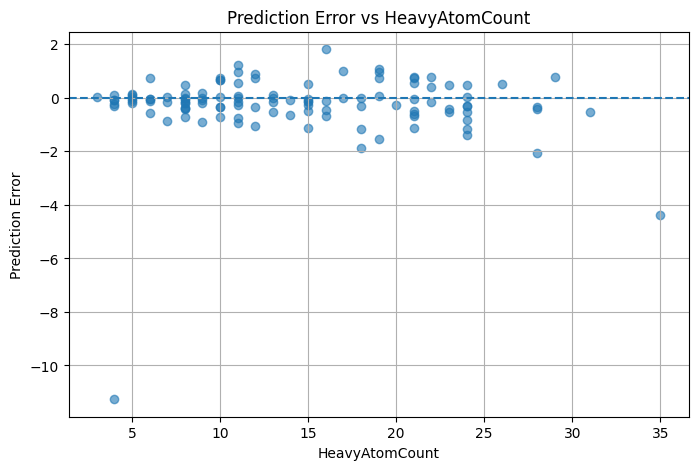

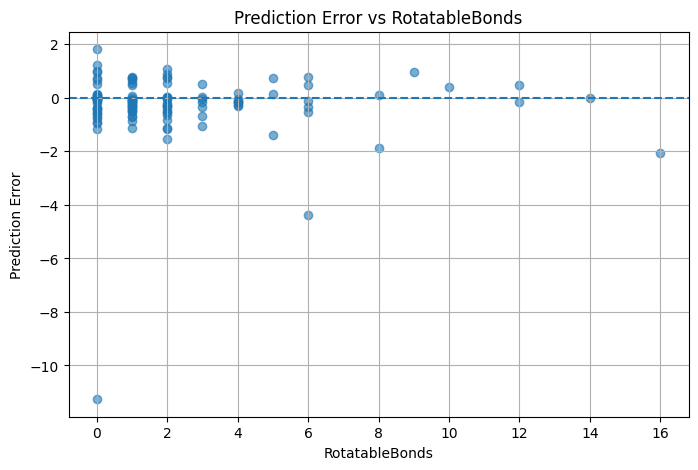


Correlation between molecular descriptors and absolute prediction error:


,Absolute_Error
NumHAcceptors,0.111412
RingCount,0.109853
HeavyAtomCount,0.103588
TPSA,0.089235
MolWt,0.085584
NumHDonors,0.073268
RotatableBonds,0.028758
LogP,0.009650


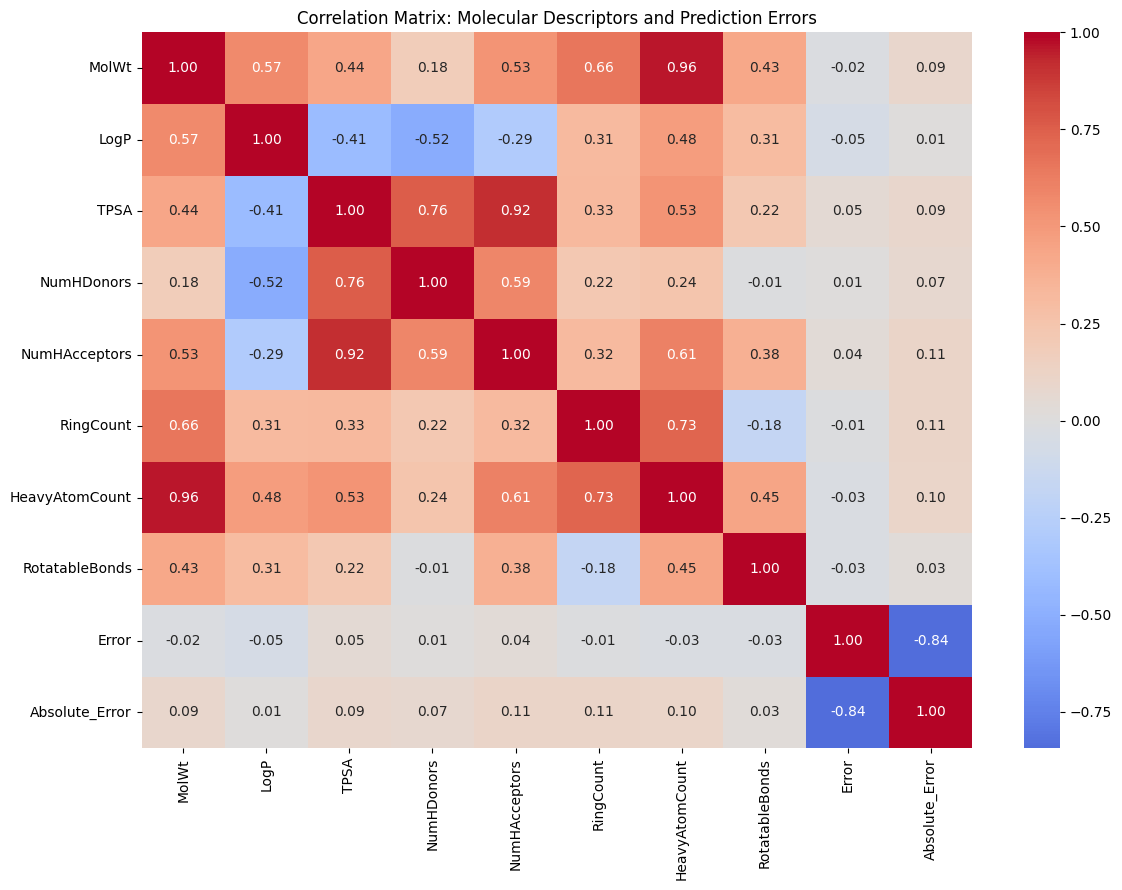

In [60]:
# ============================================================
# 5.1 ERROR ANALYSIS BASED ON MOLECULAR DESCRIPTORS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors
from deepchem.splits import RandomSplitter
from deepchem.data import NumpyDataset
from deepchem.feat import RDKitDescriptors


# ============================================================
# 1. LOAD THE ORIGINAL ESOL DATASET
# ============================================================

df_original = pd.read_csv('data/ci034243x_si_001.txt')

print("Original dataset shape:", df_original.shape)

print("\nColumns:")
print(df_original.columns.tolist())


# ============================================================
# 2. KEEP THE COLUMNS NEEDED FOR THIS ANALYSIS
# ============================================================

df_original = df_original[
    [
        'measured log(solubility:mol/L)',
        'SMILES'
    ]
].copy()


# ============================================================
# 3. CONVERT SMILES TO RDKIT MOLECULES
# ============================================================

df_original['mol'] = df_original['SMILES'].apply(
    Chem.MolFromSmiles
)

# Check for invalid molecules
invalid_molecules = df_original['mol'].isna().sum()

print("\nInvalid molecules:", invalid_molecules)

# Remove invalid molecules if necessary
df_original = df_original[
    df_original['mol'].notna()
].reset_index(drop=True)


# ============================================================
# 4. CALCULATE MOLECULAR DESCRIPTORS
# ============================================================

df_original['MolWt'] = df_original['mol'].apply(
    Descriptors.MolWt
)

df_original['LogP'] = df_original['mol'].apply(
    Descriptors.MolLogP
)

df_original['TPSA'] = df_original['mol'].apply(
    Descriptors.TPSA
)

df_original['NumHDonors'] = df_original['mol'].apply(
    Descriptors.NumHDonors
)

df_original['NumHAcceptors'] = df_original['mol'].apply(
    Descriptors.NumHAcceptors
)

df_original['RingCount'] = df_original['mol'].apply(
    Descriptors.RingCount
)

df_original['HeavyAtomCount'] = df_original['mol'].apply(
    Descriptors.HeavyAtomCount
)

df_original['RotatableBonds'] = df_original['mol'].apply(
    Descriptors.NumRotatableBonds
)


# ============================================================
# 5. CREATE DESCRIPTOR DATAFRAME
# ============================================================

descriptor_columns = [
    'SMILES',
    'measured log(solubility:mol/L)',
    'MolWt',
    'LogP',
    'TPSA',
    'NumHDonors',
    'NumHAcceptors',
    'RingCount',
    'HeavyAtomCount',
    'RotatableBonds'
]

descriptor_df = df_original[descriptor_columns].copy()

print("\nMolecular descriptor dataset:")

display(
    descriptor_df.head()
)

print("\nDescriptor dataset shape:")
print(descriptor_df.shape)


# ============================================================
# 6. GENERATE THE SAME MOLECULAR FEATURES
# ============================================================

featurizer = RDKitDescriptors()

mol_features_original = featurizer.featurize(
    df_original['SMILES'].values
)

# Remove descriptor columns containing NaN values
mol_features_original = mol_features_original[
    :,
    ~np.isnan(mol_features_original).any(axis=0)
]

print(
    "\nNumber of molecular features:",
    mol_features_original.shape[1]
)


# ============================================================
# 7. CREATE TARGET VARIABLE
# ============================================================

y_original = df_original[
    'measured log(solubility:mol/L)'
].values.reshape(-1, 1)


# ============================================================
# 8. CREATE DEEPCHEM DATASET
# ============================================================

# Store the original row index in ids.
# This will allow us to recover the correct molecules later.

dataset_original = NumpyDataset(
    X=mol_features_original,
    y=y_original,
    ids=np.arange(len(df_original))
)


# ============================================================
# 9. REPRODUCE THE ORIGINAL TRAIN / VALID / TEST SPLIT
# ============================================================

# IMPORTANT:
# The original split used seed=0.
# Therefore, we must use exactly the same seed here.

splitter = RandomSplitter()

train_original, valid_original, test_original = (
    splitter.train_valid_test_split(
        dataset_original,
        frac_train=0.8,
        frac_valid=0.1,
        frac_test=0.1,
        seed=0
    )
)


print("\nReconstructed split:")

print(
    "Training samples:",
    len(train_original)
)

print(
    "Validation samples:",
    len(valid_original)
)

print(
    "Test samples:",
    len(test_original)
)


# ============================================================
# 10. GET THE MOLECULES FROM THE TEST SET
# ============================================================

test_indices = test_original.ids.astype(int)

test_descriptor_df = descriptor_df.iloc[
    test_indices
].copy().reset_index(drop=True)


print("\nTest descriptor dataframe shape:")
print(test_descriptor_df.shape)


# ============================================================
# 11. GENERATE / ORGANIZE MODEL PREDICTIONS
# ============================================================

# Ensure predictions have shape (n_samples, 1)

predictions_analysis = np.asarray(
    predictions
).reshape(-1, 1)


# Actual test values

actual_analysis = np.asarray(
    test_dataset.y
).reshape(-1, 1)


# Calculate prediction errors

errors_analysis = (
    predictions_analysis - actual_analysis
)


# ============================================================
# 12. VERIFY DIMENSIONS
# ============================================================

print("\nChecking dimensions:")

print(
    "Test molecules :",
    len(test_descriptor_df)
)

print(
    "Predictions    :",
    len(predictions_analysis)
)

print(
    "Actual values  :",
    len(actual_analysis)
)

print(
    "Errors         :",
    len(errors_analysis)
)


if not (
    len(test_descriptor_df)
    == len(predictions_analysis)
    == len(actual_analysis)
    == len(errors_analysis)
):
    raise ValueError(
        "The number of test molecules, predictions, "
        "actual values and errors does not match."
    )


# ============================================================
# 13. ADD PREDICTIONS AND ERRORS
# ============================================================

test_descriptor_df['Actual_logS'] = (
    actual_analysis.flatten()
)

test_descriptor_df['Predicted_logS'] = (
    predictions_analysis.flatten()
)

test_descriptor_df['Error'] = (
    errors_analysis.flatten()
)

test_descriptor_df['Absolute_Error'] = np.abs(
    errors_analysis.flatten()
)


# ============================================================
# 14. VERIFY THAT TEST MOLECULES ARE CORRECTLY ALIGNED
# ============================================================

comparison = np.isclose(
    test_descriptor_df[
        'measured log(solubility:mol/L)'
    ].values,

    test_descriptor_df[
        'Actual_logS'
    ].values
)


print("\n" + "=" * 60)
print("TEST SET ALIGNMENT CHECK")
print("=" * 60)

print(
    "Matching samples:",
    comparison.sum(),
    "/",
    len(comparison)
)

print(
    "All samples match:",
    comparison.all()
)

print("=" * 60)


# Stop the analysis if molecules are not correctly aligned

if not comparison.all():
    raise ValueError(
        "The reconstructed test molecules are not aligned "
        "with the original test dataset."
    )


# ============================================================
# 15. DISPLAY FINAL TEST DATAFRAME
# ============================================================

print(
    "\nFinal dataframe for molecular descriptor error analysis:"
)

display(
    test_descriptor_df.head(10)
)


# ============================================================
# 16. ERROR STATISTICS
# ============================================================

mean_error = (
    test_descriptor_df['Error'].mean()
)

std_error = (
    test_descriptor_df['Error'].std(ddof=0)
)

median_error = (
    test_descriptor_df['Error'].median()
)

rmse_error = np.sqrt(
    np.mean(
        test_descriptor_df['Error'] ** 2
    )
)


print("\n" + "=" * 60)
print("ERROR STATISTICS")
print("=" * 60)

print(
    f"Mean Error: {mean_error:.4f}"
)

print(
    f"Standard Deviation of Error: {std_error:.4f}"
)

print(
    f"Median Error: {median_error:.4f}"
)

print(
    f"RMSE: {rmse_error:.4f}"
)

print("=" * 60)


# ============================================================
# 17. ERROR VS MOLECULAR DESCRIPTORS
# ============================================================

descriptors_to_plot = [
    'MolWt',
    'LogP',
    'TPSA',
    'NumHDonors',
    'NumHAcceptors',
    'RingCount',
    'HeavyAtomCount',
    'RotatableBonds'
]


for descriptor in descriptors_to_plot:

    plt.figure(figsize=(8, 5))

    plt.scatter(
        test_descriptor_df[descriptor],
        test_descriptor_df['Error'],
        alpha=0.6
    )

    # Reference line: zero prediction error
    plt.axhline(
        y=0,
        linestyle='--'
    )

    plt.xlabel(descriptor)

    plt.ylabel(
        'Prediction Error'
    )

    plt.title(
        f'Prediction Error vs {descriptor}'
    )

    plt.grid(True)

    plt.show()


# ============================================================
# 18. CORRELATION ANALYSIS
# ============================================================

error_correlations = (
    test_descriptor_df[
        descriptors_to_plot
        + ['Absolute_Error']
    ]
    .corr()['Absolute_Error']
    .drop('Absolute_Error')
    .sort_values(
        key=abs,
        ascending=False
    )
)


print(
    "\nCorrelation between molecular descriptors "
    "and absolute prediction error:"
)

display(
    error_correlations
)


# ============================================================
# 19. CORRELATION MATRIX
# ============================================================

correlation_columns = (
    descriptors_to_plot
    + ['Error', 'Absolute_Error']
)

correlation_matrix = (
    test_descriptor_df[
        correlation_columns
    ].corr()
)


plt.figure(
    figsize=(12, 9)
)

import seaborn as sns

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix: Molecular Descriptors and Prediction Errors"
)

plt.tight_layout()

plt.show()

### Correlation Analysis of Molecular Descriptors and Prediction Error

The correlation analysis shows that none of the molecular descriptors has a strong linear relationship with the absolute prediction error.

The highest correlations were observed for the **number of H-bond acceptors** (0.111), **ring count** (0.110), and **heavy atom count** (0.104). However, these correlations are still very weak.

Other descriptors such as molecular weight, TPSA, and number of H-bond donors also showed weak correlations with the absolute error. In particular, **LogP** showed an almost negligible correlation (0.010).

These results suggest that the model's largest prediction errors cannot be explained by a single molecular descriptor alone. Instead, the errors may depend on more complex combinations of molecular properties and structural characteristics.

It is also important to note that this analysis evaluates linear correlations with the absolute prediction error. Therefore, weak Pearson correlations do not necessarily imply that the descriptors have no influence on model performance; nonlinear relationships may still exist.

Perform correlation analysis in molecular descriptors

In [62]:
# ============================================================
# 6. CORRELATION ANALYSIS
# ============================================================

# Select only molecular descriptors and prediction error
desc_df = test_descriptor_df[
    [
        'MolWt',
        'LogP',
        'TPSA',
        'NumHDonors',
        'NumHAcceptors',
        'RingCount',
        'HeavyAtomCount',
        'RotatableBonds',
        'Error'
    ]
].copy()

# Rename Error -> error to follow the original notebook
desc_df = desc_df.rename(columns={'Error': 'error'})


# Calculate correlations between prediction error
# and molecular descriptors
correlation = (
    desc_df
    .corr(numeric_only=True)['error']
    .drop('error')
    .sort_values()
)


print("\nCorrelations between error and molecular descriptors:")
print("----------------------------------------------------")

print("\nTop 5 descriptors most negatively correlated:")
print(correlation.head(5))

print("\nTop 5 descriptors most positively correlated:")
print(correlation.tail(5).sort_values(ascending=False))



Correlations between error and molecular descriptors:
----------------------------------------------------

Top 5 descriptors most negatively correlated:
LogP             -0.054822
RotatableBonds   -0.029571
HeavyAtomCount   -0.028636
MolWt            -0.022016
RingCount        -0.013060
Name: error, dtype: float64

Top 5 descriptors most positively correlated:
TPSA             0.050192
NumHAcceptors    0.038776
NumHDonors       0.011673
RingCount       -0.013060
MolWt           -0.022016
Name: error, dtype: float64


### Correlation Analysis: Prediction Error vs. Molecular Descriptors

The correlation analysis shows that all molecular descriptors have very weak linear correlations with the signed prediction error.

The strongest negative correlation was observed for **LogP**:

$$
r = -0.0548
$$

while the strongest positive correlation was observed for **TPSA**:

$$
r = 0.0502
$$

Since all correlation coefficients are close to zero, there is no strong linear evidence that any individual molecular descriptor systematically determines whether the model overestimates or underestimates solubility.

This result is consistent with the previous analysis of absolute prediction error, where the correlations were also weak. Overall, the prediction errors are likely influenced by more complex combinations of molecular properties rather than by a single descriptor.

Plot the 3 most influential descriptors on the error


Analyzing the 3 most influential descriptors on the error:
['LogP', 'TPSA', 'NumHAcceptors']


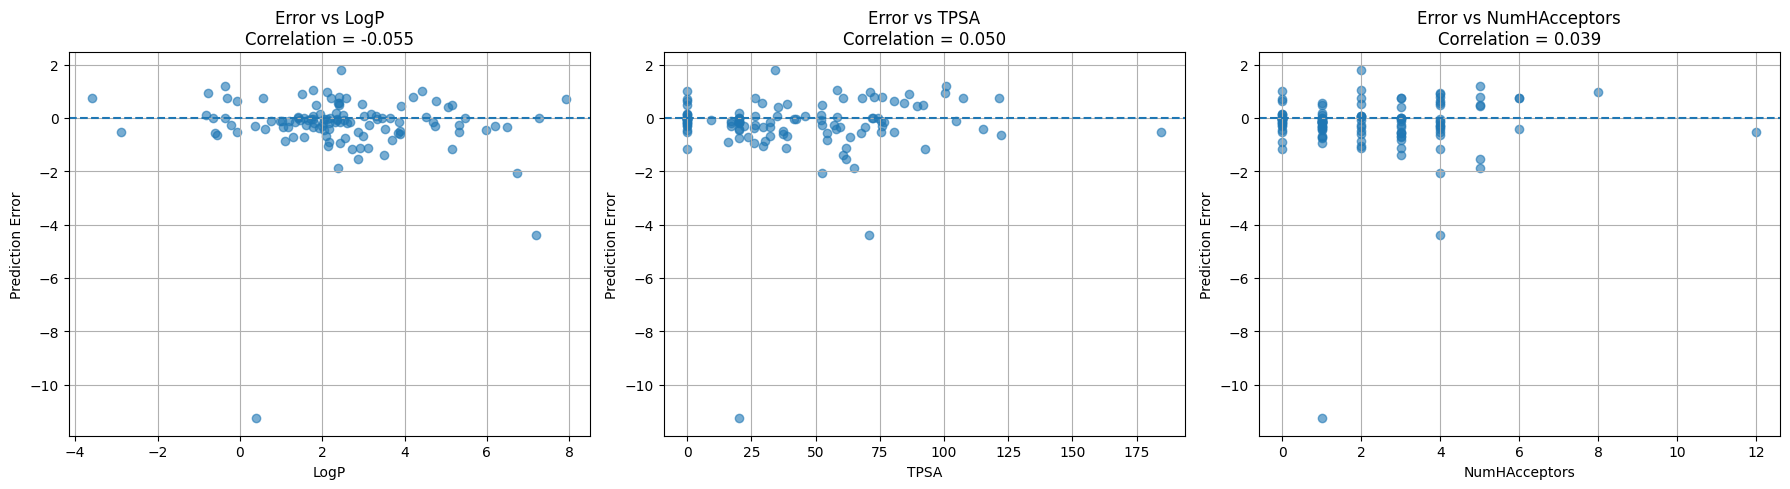

In [64]:
# ============================================================
# 7. VISUALIZATION
# ============================================================

# Select the 3 descriptors with the strongest absolute
# correlation with prediction error
top_corr = (
    correlation
    .abs()
    .sort_values(ascending=False)
    .head(3)
    .index
)

print("\nAnalyzing the 3 most influential descriptors on the error:")
print(list(top_corr))


# Create plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, descriptor in enumerate(top_corr):

    axes[i].scatter(
        desc_df[descriptor],
        desc_df['error'],
        alpha=0.6
    )

    # Zero-error reference line
    axes[i].axhline(
        y=0,
        linestyle='--'
    )

    axes[i].set_xlabel(descriptor)
    axes[i].set_ylabel('Prediction Error')

    axes[i].set_title(
        f'Error vs {descriptor}\n'
        f'Correlation = {correlation[descriptor]:.3f}'
    )

    axes[i].grid(True)


plt.tight_layout()
plt.show()

### Analysis of Prediction Error vs. Molecular Descriptors

The three descriptors with the highest absolute correlation with the signed prediction error were **LogP**, **TPSA**, and **Number of H-Bond Acceptors**.

Their correlation coefficients were:

- **LogP:** -0.055
- **TPSA:** 0.050
- **Number of H-Bond Acceptors:** 0.039

Despite being the three largest absolute correlations, all values are very close to zero. The scatter plots also show no clear linear trend between these molecular descriptors and the prediction error.

Therefore, there is no strong evidence that any of these individual descriptors systematically causes the model to overestimate or underestimate molecular solubility. The prediction errors may instead depend on more complex and nonlinear combinations of molecular properties.

The plots also reveal some large prediction errors (outliers), suggesting that particular molecules may be considerably more difficult for the model to predict.

## TODO
 Analyze the relationship between molecular descriptors and prediction error.

 Instructions:
 - Observe the scatter plots of error vs each descriptor.
 - Identify any visible patterns or trends.

# Final Reflection

Before reading the interpretation below, answer the following questions based on your analysis:

- Which descriptor showed the strongest relationship with prediction error?
- Did the model tend to overestimate or underestimate solubility?
- For which type of molecules (e.g., polar, non-polar, flexible) did the model perform worse?
- What is one possible reason for this behavior?

## Analysis of Molecular Descriptors and Prediction Error

The scatter plots show that there is no strong linear relationship between any individual molecular descriptor and the prediction error. The points are widely dispersed around zero, and the correlation coefficients are very small.

Among the descriptors analyzed, **LogP showed the strongest relationship with prediction error**, with a correlation of approximately **-0.055**. However, this correlation is extremely weak, so it should not be interpreted as a strong dependence.

TPSA and the number of H-bond acceptors also showed very weak correlations of approximately **0.050** and **0.039**, respectively. Overall, the results suggest that prediction errors cannot be explained by a single molecular descriptor.

### Final Reflection

**1. Which descriptor showed the strongest relationship with prediction error?**

Among the descriptors analyzed, **LogP** showed the strongest relationship with the signed prediction error, with a correlation of approximately **-0.055**. Nevertheless, this relationship is very weak.

**2. Did the model tend to overestimate or underestimate solubility?**

The model showed a slight tendency to **underestimate solubility**. The mean prediction error was approximately **-0.249**, where the error was defined as:

$$
\text{Error} = \text{Predicted} - \text{Actual}
$$

Therefore, the negative mean error indicates that, on average, the predicted log-solubility values were slightly lower than the experimental values.

**3. For which type of molecules did the model perform worse?**

There is no clear evidence that the model systematically performs worse for a specific type of molecule based on the descriptors analyzed. LogP, TPSA, H-bond acceptors, molecular weight, ring count, and molecular flexibility all showed weak correlations with prediction error.

Although some large individual errors are visible in the scatter plots, they do not form a clear pattern associated with highly polar, non-polar, or flexible molecules.

**4. What is one possible reason for this behavior?**

One possible explanation is that molecular solubility depends on complex and nonlinear interactions between multiple structural and physicochemical properties. Therefore, prediction errors may not be determined by a single descriptor such as LogP or TPSA.

In addition, the test set contains only **115 molecules**, and a few molecules show unusually large prediction errors. These difficult cases can affect the overall performance metrics even when most predictions are relatively close to the experimental values.

## 6. Biological Interpretation of Prediction Errors

### Correlation Between Molecular Descriptors and Prediction Errors

To understand the biological relevance of the prediction errors, we analyzed their correlation with various molecular descriptors.

#### 1. **LogP** (Correlation ≈ +0.29)
- **Meaning**: LogP represents a molecule’s lipophilicity (affinity for non-polar environments).
- **Observation**: Higher LogP values are associated with **positive prediction errors** (i.e., solubility overestimated).
- **Biological Insight**: Lipophilic molecules tend to be less soluble in water. The model appears to **underestimate this effect**, possibly due to insufficient representation of highly lipophilic compounds in the training set.

#### 2. **Rotatable Bonds** (Correlation ≈ +0.28)
- **Meaning**: Number of flexible bonds that can rotate freely.
- **Observation**: Molecules with more rotatable bonds tend to have **higher positive errors**.
- **Biological Insight**: Flexibility may affect solubility in complex ways, but the model may be **overestimating** its contribution.

#### 3. **TPSA (Topological Polar Surface Area)** (Correlation ≈ -0.19)
- **Meaning**: A measure of molecular polarity and hydrogen bonding potential.
- **Observation**: Higher TPSA is linked to **negative prediction errors** (i.e., solubility underestimated).
- **Biological Insight**: Molecules with large polar surface areas tend to be more water-soluble, and the model appears to **undervalue** this feature.


- Clear trend: **From underestimation to overestimation** as LogP increases.
- Suggests the model **overpredicts solubility** for lipophilic (non-polar) compounds.


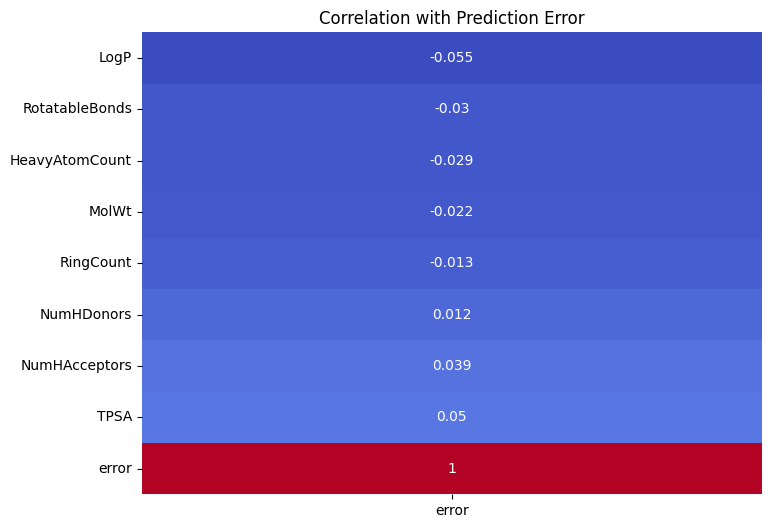

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = desc_df.corr(numeric_only=True)['error'].sort_values()
plt.figure(figsize=(8, 6))
sns.heatmap(corr.to_frame(), annot=True, cmap="coolwarm", cbar=False)
plt.title('Correlation with Prediction Error')
plt.show()


### Correlation with Prediction Error

The correlation heatmap confirms that none of the analyzed molecular descriptors shows a strong linear relationship with the prediction error.

**LogP** has the strongest negative correlation with the error ($r=-0.055$), while **TPSA** has the strongest positive correlation ($r=0.050$). However, both values are very close to zero, indicating extremely weak linear relationships.

The remaining descriptors also show correlations close to zero. Therefore, the model does not appear to systematically overestimate or underestimate solubility based on any single molecular descriptor.

The value of 1.0 for `error` corresponds to the correlation of the error variable with itself and is not a molecular descriptor.

Overall, the results suggest that prediction errors may arise from more complex and nonlinear combinations of molecular properties rather than from a single descriptor.